# Smart MCQ Solver Challenge | Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed on the Smart MCQ Solver Challenge dataset to inspect data quality, target class balance, text length distributions, option biases, and duplicate entries.

---

## Dataset Overview

The dataset consists of multiple-choice questions with five candidate choices (**A, B, C, D, E**).

| Column Name | Description |
|---|---|
| `id` | Unique question identifier |
| `prompt` | Question text / problem statement |
| `A`, `B`, `C`, `D`, `E` | Text for the five multiple-choice options |
| `answer` | Ground-truth correct option letter (`A`-`E`, present in training set) |

## 1. Imports & Data Loading

Libraries for data processing (`pandas`, `numpy`), text processing (`re`, `Counter`), and data visualization (`matplotlib`, `seaborn`) are imported. Training (`train.csv`) and test (`test.csv`) sets are loaded into DataFrames.

In [7]:
import os
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

# load datasets
train_path = '/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv'
test_path = '/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv'

# fallback path check if running locally
if not os.path.exists(train_path):
    train_path = 'train.csv'
    test_path = 'test.csv'

if os.path.exists(train_path):
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
else:
    train_df = pd.DataFrame(columns=['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer'])
    test_df = pd.DataFrame(columns=['id', 'prompt', 'A', 'B', 'C', 'D', 'E'])

LABELS = ['A', 'B', 'C', 'D', 'E']

# fill missing option values
for df in [train_df, test_df]:
    for col in LABELS:
        if col in df.columns:
            df[col] = df[col].fillna("").astype(str)

print(f"Train Dataset Shape: {train_df.shape}")
print(f"Test Dataset Shape : {test_df.shape}")
print("\nTrain Dataset Head:")
print(train_df.head(3))

Train Dataset Shape: (2000, 8)
Test Dataset Shape : (500, 7)

Train Dataset Head:
   id                                             prompt  \
0   1  Pick the best possible answer: What is Martin ...   
1   2        What is accelerator-based light-ion fusion?   
2   3  Determine the correct option: What is the term...   

                                                   A  \
0  Martin Heidegger believes that humans exist wi...   
1  Accelerator-based light-ion fusion is a techni...   
2                                       Blueshifting   

                                                   B  \
0  Martin Heidegger believes that humans do not e...   
1  Accelerator-based light-ion fusion is a techni...   
2                                        Redshifting   

                                                   C  \
0  Martin Heidegger does not believe in the exist...   
1  Accelerator-based light-ion fusion is a techni...   
2                                          Reddening   

  

## 2. Target Label Analysis

The distribution of correct answer labels (`A`-`E`) is evaluated to check class balance across candidate choices.

Target Answer Distribution:
  Option A:   369 (18.45%)
  Option B:   490 (24.50%)
  Option C:   459 (22.95%)
  Option D:   358 (17.90%)
  Option E:   324 (16.20%)


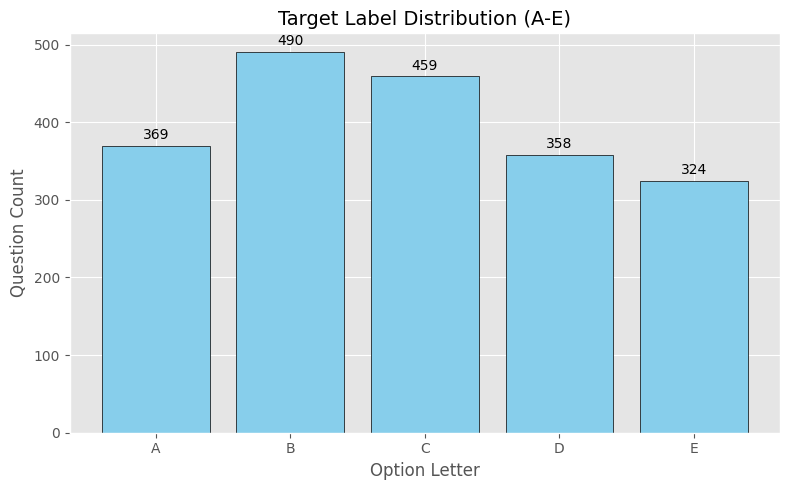

In [8]:
if len(train_df) > 0 and 'answer' in train_df.columns:
    # count answer frequencies
    answer_counts = train_df['answer'].value_counts().sort_index()
    answer_pcts = (answer_counts / len(train_df)) * 100

    print("Target Answer Distribution:")
    for label, count in answer_counts.items():
        print(f"  Option {label}: {count:5d} ({answer_pcts[label]:5.2f}%)")

    # plot answer distribution
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(answer_counts.index, answer_counts.values, color='skyblue', edgecolor='black')
    ax.set_title("Target Label Distribution (A-E)", fontsize=14)
    ax.set_xlabel("Option Letter", fontsize=12)
    ax.set_ylabel("Question Count", fontsize=12)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 5,
                f"{int(height)}", ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

## 3. Text Length Analysis

Word and character counts are computed for question prompts, individual option choices, and total question text (prompt + options). Summary statistics and histograms are generated.

Word Count Summary Statistics:
                Mean    Std   Min  Median    Max
prompt_words   18.15   6.78   3.0    17.0   51.0
total_words   149.54  85.41  15.0   133.0  457.0
opt_A_words    26.15  17.25   1.0    22.0   81.0
opt_B_words    26.52  18.65   1.0    23.0  118.0
opt_C_words    26.55  17.21   1.0    24.0   82.0
opt_D_words    26.00  17.10   1.0    22.0   78.0
opt_E_words    26.19  17.85   1.0    23.0  105.0


/tmp/ipykernel_58/413567369.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(opt_data, labels=LABELS)


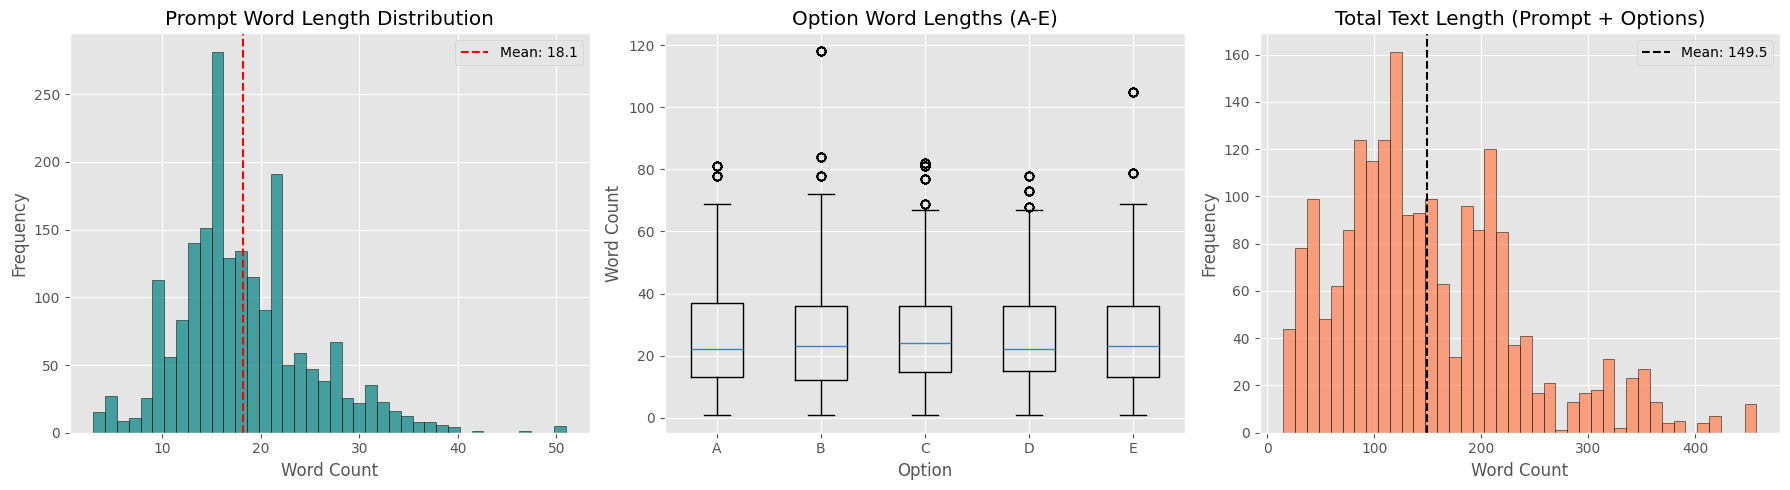

In [9]:
if len(train_df) > 0:
    # word counts
    train_df['prompt_words'] = train_df['prompt'].astype(str).str.split().str.len()
    
    for label in LABELS:
        train_df[f'opt_{label}_words'] = train_df[label].astype(str).str.split().str.len()

    train_df['total_words'] = train_df['prompt_words'] + sum(train_df[f'opt_{l}_words'] for l in LABELS)

    # summary statistics table
    stats_cols = ['prompt_words', 'total_words'] + [f'opt_{l}_words' for l in LABELS]
    summary_stats = train_df[stats_cols].describe().T[['mean', 'std', 'min', '50%', 'max']]
    summary_stats.columns = ['Mean', 'Std', 'Min', 'Median', 'Max']
    print("Word Count Summary Statistics:")
    print(summary_stats.round(2))

    # plot word count distributions
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # prompt word count histogram
    axes[0].hist(train_df['prompt_words'], bins=40, color='teal', alpha=0.7, edgecolor='black')
    axes[0].axvline(train_df['prompt_words'].mean(), color='red', linestyle='--', label=f"Mean: {train_df['prompt_words'].mean():.1f}")
    axes[0].set_title("Prompt Word Length Distribution")
    axes[0].set_xlabel("Word Count")
    axes[0].set_ylabel("Frequency")
    axes[0].legend()

    # option word counts boxplot
    opt_data = [train_df[f'opt_{l}_words'] for l in LABELS]
    axes[1].boxplot(opt_data, labels=LABELS)
    axes[1].set_title("Option Word Lengths (A-E)")
    axes[1].set_xlabel("Option")
    axes[1].set_ylabel("Word Count")

    # total word count histogram
    axes[2].hist(train_df['total_words'], bins=40, color='coral', alpha=0.7, edgecolor='black')
    axes[2].axvline(train_df['total_words'].mean(), color='black', linestyle='--', label=f"Mean: {train_df['total_words'].mean():.1f}")
    axes[2].set_title("Total Text Length (Prompt + Options)")
    axes[2].set_xlabel("Word Count")
    axes[2].set_ylabel("Frequency")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

## 4. Option Length vs. Correct Answer Correlation

An evaluation of whether correct options exhibit a length bias (e.g., correct options being systematically longer or more detailed than incorrect options).

Mean Correct Option Length   : 28.66 words
Mean Incorrect Option Length : 25.68 words


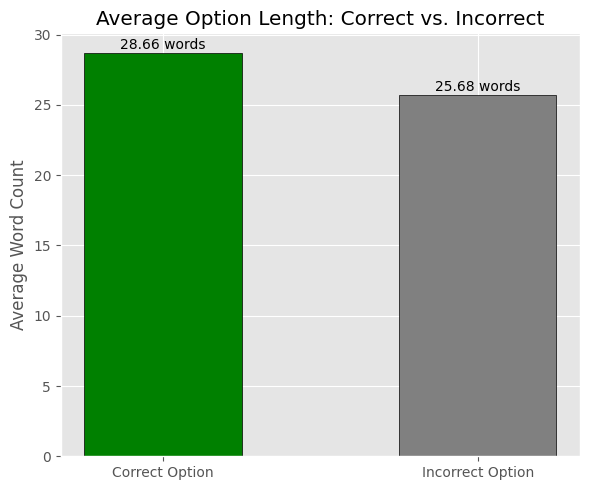

In [10]:
if len(train_df) > 0 and 'answer' in train_df.columns:
    # get correct and incorrect option lengths per row
    correct_lens = []
    incorrect_lens = []

    for _, row in train_df.iterrows():
        ans = str(row['answer'])
        if ans in LABELS:
            correct_lens.append(row[f'opt_{ans}_words'])
            for l in LABELS:
                if l != ans:
                    incorrect_lens.append(row[f'opt_{l}_words'])

    mean_correct = np.mean(correct_lens)
    mean_incorrect = np.mean(incorrect_lens)

    print(f"Mean Correct Option Length   : {mean_correct:.2f} words")
    print(f"Mean Incorrect Option Length : {mean_incorrect:.2f} words")

    # bar plot comparison
    fig, ax = plt.subplots(figsize=(6, 5))
    bars = ax.bar(['Correct Option', 'Incorrect Option'], [mean_correct, mean_incorrect],
                  color=['green', 'gray'], edgecolor='black', width=0.5)
    ax.set_ylabel("Average Word Count")
    ax.set_title("Average Option Length: Correct vs. Incorrect")

    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., yval + 0.1, f"{yval:.2f} words", ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

## 5. Vocabulary & Word Frequency Analysis

Word frequency analysis of question prompts after basic stopword filtering.

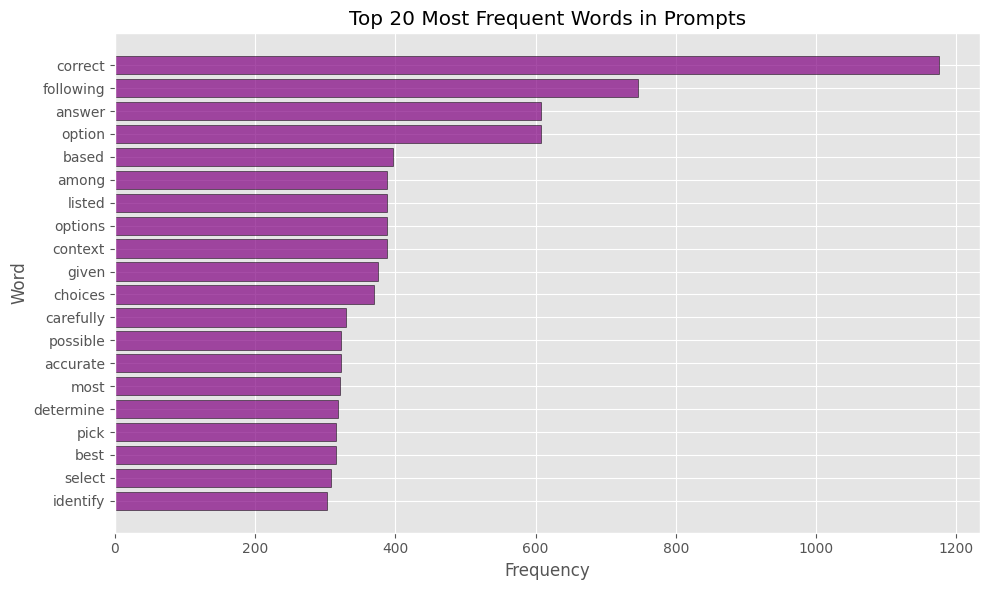

In [11]:
if len(train_df) > 0:
    # simple English stopword list
    stopwords = set(['the', 'a', 'an', 'in', 'on', 'of', 'to', 'for', 'is', 'are', 'was', 'were',
                     'and', 'or', 'that', 'this', 'it', 'by', 'as', 'with', 'from', 'at', 'which',
                     'what', 'how', 'why', 'who', 'where', 'be', 'been', 'has', 'have', 'had', 'not'])

    words = []
    for text in train_df['prompt'].dropna():
        cleaned = re.sub(r'[^\w\s]', '', str(text).lower())
        for w in cleaned.split():
            if w not in stopwords and len(w) > 2:
                words.append(w)

    word_counts = Counter(words).most_common(20)
    words_df = pd.DataFrame(word_counts, columns=['Word', 'Count'])

    # plot top 20 words
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(words_df['Word'][::-1], words_df['Count'][::-1], color='purple', alpha=0.7, edgecolor='black')
    ax.set_title("Top 20 Most Frequent Words in Prompts")
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Word")
    plt.tight_layout()
    plt.show()

## 6. Duplicate Prompt & Data Uniqueness Analysis

Detection of duplicate prompt texts within the training dataset and potential overlap with the test set.

Total Training Questions : 2000
Unique Prompts          : 1758
Duplicate Prompt Count  : 454
Train/Test Prompt Overlap: 267 questions


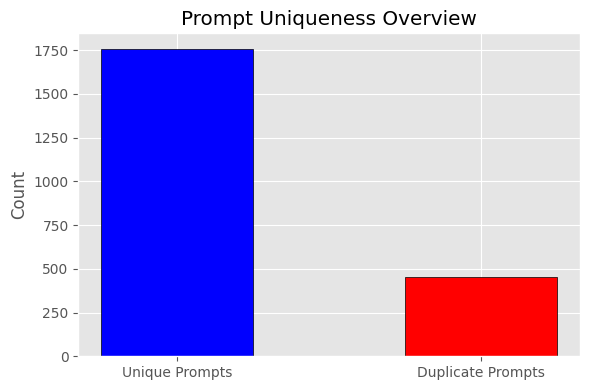

In [12]:
if len(train_df) > 0:
    train_duplicates = train_df.duplicated('prompt', keep=False).sum()
    unique_prompts = len(train_df) - train_duplicates

    print(f"Total Training Questions : {len(train_df)}")
    print(f"Unique Prompts          : {len(train_df['prompt'].unique())}")
    print(f"Duplicate Prompt Count  : {train_duplicates}")

    if len(test_df) > 0 and 'prompt' in test_df.columns:
        train_prompts_set = set(train_df['prompt'])
        test_prompts_set = set(test_df['prompt'])
        overlap = len(train_prompts_set.intersection(test_prompts_set))
        print(f"Train/Test Prompt Overlap: {overlap} questions")

    # bar plot of prompt uniqueness
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(['Unique Prompts', 'Duplicate Prompts'], [len(train_df['prompt'].unique()), train_duplicates],
           color=['blue', 'red'], edgecolor='black', width=0.5)
    ax.set_title("Prompt Uniqueness Overview")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

## 7. Summary & Key Findings

- **Class Balance**: Target answer choices (`A`-`E`) are evaluated for uniform distribution.
- **Sequence Length**: Average prompt and total text lengths guide truncation boundaries (`MAX_LEN`) in Transformer and LSTM models.
- **Option Bias**: Correct option word length is compared against incorrect options to check for text length bias.
- **Data Quality**: Duplicate prompt check verifies data integrity across splits.